# Task 2 – Heart Disease (UCI) – Drzewo decyzyjne

## Cel zadania

Celem zadania jest analiza zbioru danych Heart Disease z repozytorium UCI,
przygotowanie danych do modelowania, budowa modelu klasyfikacyjnego opartego
na drzewie decyzyjnym oraz przeprowadzenie eksperymentów badających wpływ
wybranych parametrów na jakość klasyfikacji.

## Opis zbioru danych

Wykorzystany zbiór danych pochodzi z repozytorium UCI Machine Learning Repository.
W dokumentacji podano, że baza Heart Disease zawiera 76 atrybutów, jednak
w opublikowanych eksperymentach najczęściej wykorzystywany jest podzbiór 14 cech.
Szczególnie często używana jest baza Cleveland.

Zmienna docelowa `num` przyjmuje wartości od 0 do 4, gdzie 0 oznacza brak choroby,
a wartości 1–4 oznaczają jej obecność. W niniejszym zadaniu problem zostaje
sprowadzony do klasyfikacji binarnej:
- 0 – brak choroby,
- 1 – obecność choroby (`num > 0`).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

## Import bibliotek

W analizie wykorzystano biblioteki `pandas` i `numpy` do pracy z danymi,
`matplotlib` i `seaborn` do wizualizacji oraz `scikit-learn` do budowy modelu
uczenia maszynowego i oceny jego jakości.

In [2]:
def load_heart_data():
    heart = fetch_ucirepo(id=45)
    X = heart.data.features.copy()
    y = heart.data.targets.copy()
    df = pd.concat([X, y], axis=1)
    return df

In [3]:
df = load_heart_data()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Wczytanie danych

Dane zostały pobrane bezpośrednio z repozytorium UCI przy pomocy pakietu `ucimlrepo`.
Do dalszej analizy wykorzystano standardowo stosowaną bazę Cleveland.

In [4]:
df["target"] = (df["num"] > 0).astype(int)
df.shape

(303, 15)

In [5]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
target        int64
dtype: object

In [6]:
df.isna().sum().sort_values(ascending=False)

ca          4
thal        2
age         0
trestbps    0
chol        0
sex         0
cp          0
restecg     0
fbs         0
thalach     0
exang       0
slope       0
oldpeak     0
num         0
target      0
dtype: int64

In [7]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

## Wstępna analiza danych

Na tym etapie sprawdzono rozmiar zbioru, typy danych, liczbę brakujących wartości
oraz liczebność klas zmiennej docelowej. Jest to konieczne przed rozpoczęciem
budowy modelu i etapu preprocessingu.

In [8]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

X = df[categorical_cols + numeric_cols]
y = df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

## Przygotowanie danych

W preprocessing'u zastosowano dwa różne sposoby obsługi braków danych.
Dla cech liczbowych użyto imputacji medianą, ponieważ jest ona odporna na wartości odstające.
Dla cech kategorycznych zastosowano imputację najczęściej występującą wartością oraz kodowanie One-Hot Encoding, aby nie narzucać sztucznego porządku pomiędzy kategoriami.

In [11]:
def create_tree_model(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
):
    tree_clf = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )

    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", tree_clf)
    ])
    return model    

## Model drzewa decyzyjnego

Drzewo decyzyjne dzieli dane na kolejne grupy na podstawie warunków
dotyczących wartości cech. W każdym węźle wybierany jest taki podział,
który najlepiej rozdziela klasy.

Najważniejsze parametry modelu:
- `criterion` – sposób oceny jakości podziału (`gini` lub `entropy`),
- `max_depth` – maksymalna głębokość drzewa,
- `min_samples_split` – minimalna liczba próbek potrzebna do dalszego podziału,
- `min_samples_leaf` – minimalna liczba próbek w liściu.

In [12]:
base_model = create_tree_model()
base_model.fit(X_train, y_train)

y_pred = base_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy (model bazowy): {acc:.3f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy (model bazowy): 0.754

Classification report:

              precision    recall  f1-score   support

           0       0.85      0.67      0.75        33
           1       0.69      0.86      0.76        28

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



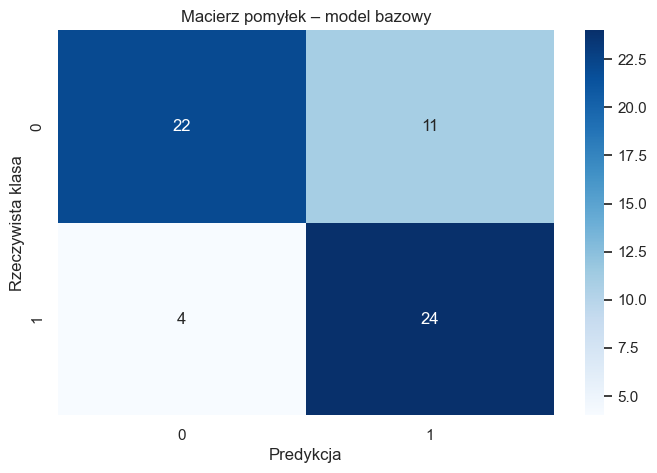

In [13]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.title("Macierz pomyłek – model bazowy")
plt.show()

## Ocena modelu bazowego

Model bazowy został wytrenowany z domyślnymi parametrami.
Na tym etapie oceniana jest jego skuteczność, aby uzyskać punkt odniesienia
dla dalszych eksperymentów z hiperparametrami.

In [14]:
def evaluate_max_depth(depth_values):
    results = []
    for d in depth_values:
        model = create_tree_model(max_depth=d)
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)

        results.append({
            "max_depth": d,
            "acc_train": acc_train,
            "acc_test": acc_test
        })
    return pd.DataFrame(results)

In [15]:
depth_values = [None, 2, 3, 4, 5, 6, 8, 10]
depth_results = evaluate_max_depth(depth_values)
depth_results

,max_depth,acc_train,acc_test
0,NaN,1.000000,0.754098
1,2.0,0.772727,0.770492
2,3.0,0.842975,0.868852
3,4.0,0.880165,0.786885
4,5.0,0.925620,0.786885
5,6.0,0.958678,0.803279
6,8.0,0.995868,0.737705
7,10.0,1.000000,0.754098


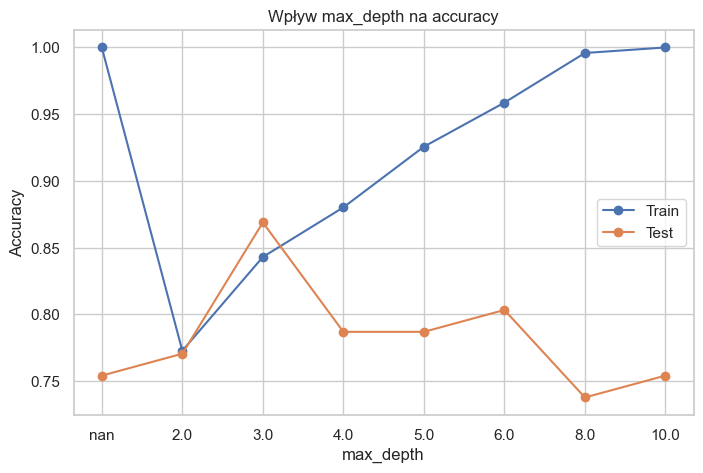

In [16]:
plot_depth = depth_results.copy()

x = range(len(plot_depth))
labels = plot_depth["max_depth"].astype(str).tolist()

plt.plot(x, plot_depth["acc_train"], marker="o", label="Train")
plt.plot(x, plot_depth["acc_test"], marker="o", label="Test")
plt.xticks(x, labels)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Wpływ max_depth na accuracy")
plt.legend()
plt.show()

## Eksperyment 1 – wpływ parametru `max_depth`

Wraz ze wzrostem `max_depth` rośnie dokładność na zbiorze treningowym.
Jednocześnie po przekroczeniu pewnej głębokości dokładność na zbiorze testowym
przestaje się poprawiać, co wskazuje na przeuczenie modelu.
Najlepsze wyniki uzyskiwane są dla umiarkowanej głębokości drzewa.

In [17]:
def evaluate_min_samples_leaf(leaf_values, fixed_depth=None):
    results = []
    for leaf in leaf_values:
        model = create_tree_model(max_depth=fixed_depth, min_samples_leaf=leaf)
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)

        results.append({
            "min_samples_leaf": leaf,
            "acc_train": acc_train,
            "acc_test": acc_test
        })
    return pd.DataFrame(results)

In [18]:
leaf_values = [1, 2, 3, 5, 10]
leaf_results = evaluate_min_samples_leaf(leaf_values, fixed_depth=4)
leaf_results

,min_samples_leaf,acc_train,acc_test
0,1,0.880165,0.786885
1,2,0.876033,0.786885
2,3,0.876033,0.786885
3,5,0.867769,0.770492
4,10,0.842975,0.868852


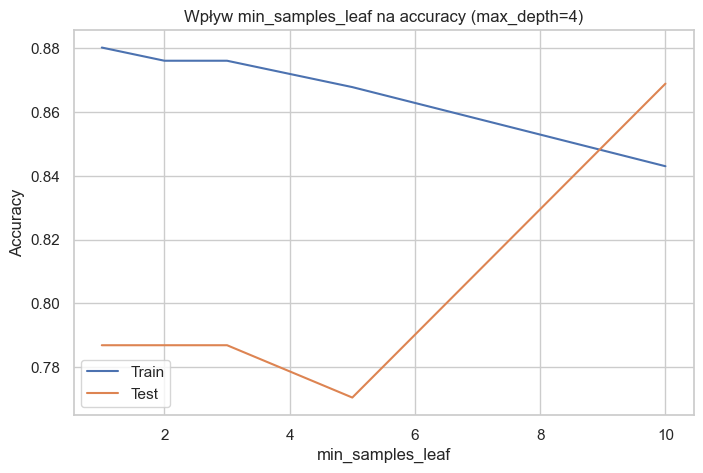

In [19]:
plt.plot(leaf_results["min_samples_leaf"], leaf_results["acc_train"], label="Train")
plt.plot(leaf_results["min_samples_leaf"], leaf_results["acc_test"], label="Test")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Wpływ min_samples_leaf na accuracy (max_depth=4)")
plt.legend()
plt.show()

## Eksperyment 2 – wpływ parametru `min_samples_leaf`

Parametr `min_samples_leaf` kontroluje minimalną liczbę próbek w liściu.
Większe wartości upraszczają drzewo i zmniejszają ryzyko przeuczenia,
ale zbyt duże mogą pogarszać jakość klasyfikacji.

In [20]:
def evaluate_criterion(criteria, fixed_depth=None):
    results = []
    for crit in criteria:
        model = create_tree_model(criterion=crit, max_depth=fixed_depth)
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)

        results.append({
            "criterion": crit,
            "acc_train": acc_train,
            "acc_test": acc_test
        })
    return pd.DataFrame(results)

In [21]:
criterion_results = evaluate_criterion(["gini", "entropy"], fixed_depth=4)
criterion_results

,criterion,acc_train,acc_test
0,gini,0.880165,0.786885
1,entropy,0.867769,0.786885


## Eksperyment 3 – wpływ parametru `criterion`

Porównano dwa kryteria podziału: `gini` i `entropy`.
W badanym przypadku oba kryteria dały zbliżone wyniki, co sugeruje,
że większy wpływ na jakość modelu miały parametry ograniczające złożoność drzewa
niż samo kryterium podziału.

In [22]:
best_model = create_tree_model(max_depth=4, min_samples_leaf=2)
best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"AUC (ROC) dla najlepszego modelu: {auc:.3f}")

AUC (ROC) dla najlepszego modelu: 0.874


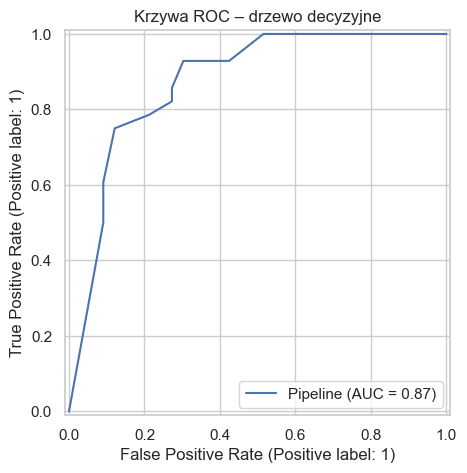

In [23]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Krzywa ROC – drzewo decyzyjne")
plt.show()

## Krzywa ROC

Krzywa ROC pokazuje zależność pomiędzy odsetkiem poprawnie wykrytych przypadków pozytywnych
a odsetkiem przypadków fałszywie dodatnich przy różnych progach decyzji.
Im większa wartość AUC i im bardziej krzywa zbliża się do lewego górnego rogu,
tym lepiej model rozróżnia klasy.

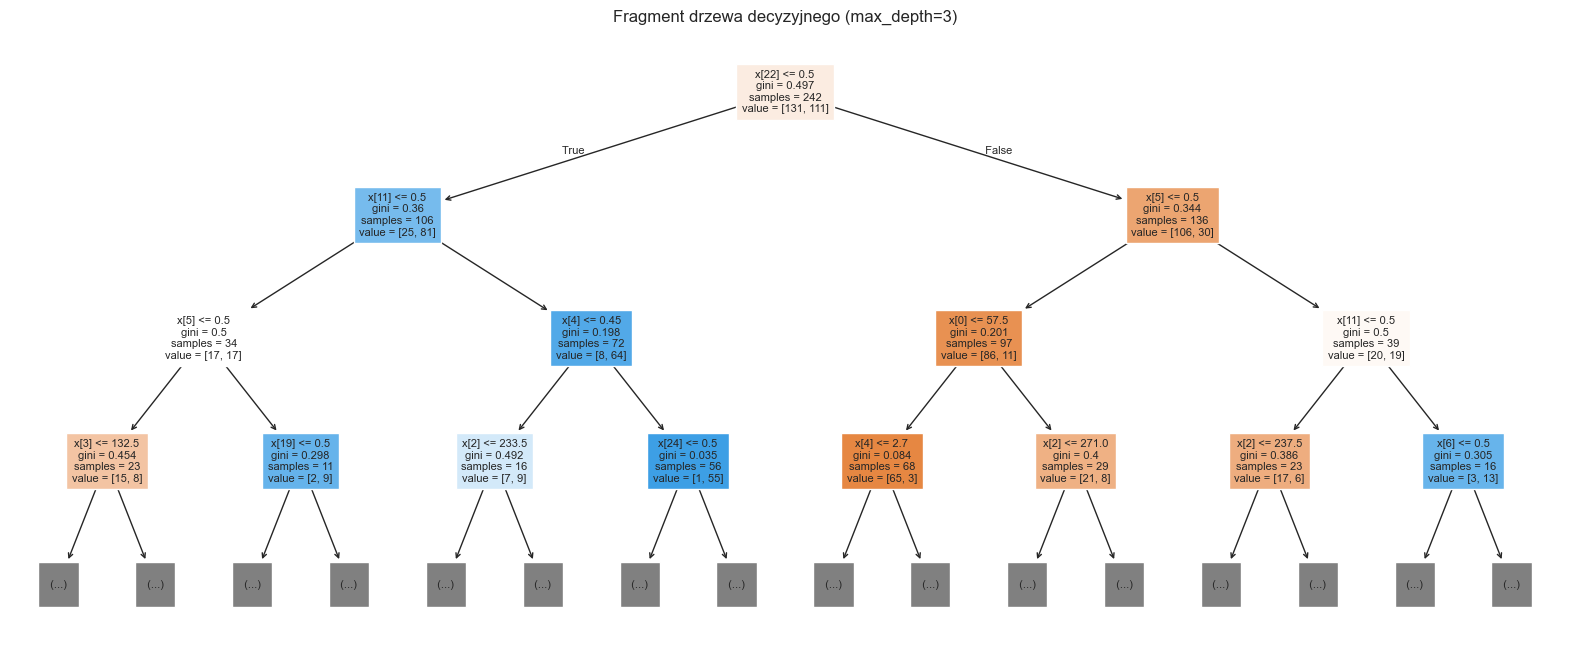

In [24]:
clf = best_model.named_steps["clf"]

plt.figure(figsize=(20, 8))
plot_tree(
    clf,
    max_depth=3,
    fontsize=8,
    filled=True
)
plt.title("Fragment drzewa decyzyjnego (max_depth=3)")
plt.show()

## Wizualizacja drzewa

Na wykresie przedstawiono fragment wytrenowanego drzewa decyzyjnego.
Węzły położone bliżej korzenia mają największy wpływ na podział danych.
Wizualizacja pozwala lepiej zrozumieć sposób podejmowania decyzji przez model.

## Wnioski końcowe

W zbiorze danych występowały brakujące wartości oraz cechy kategoryczne,
dlatego konieczne było zastosowanie preprocessingu przed budową modelu.

Przeprowadzone eksperymenty pokazały, że zbyt głębokie drzewo prowadzi do przeuczenia,
natomiast umiarkowane ograniczenie złożoności modelu poprawia jego zdolność generalizacji.

Drzewo decyzyjne okazało się modelem łatwym do interpretacji i pozwoliło
na uzyskanie zadowalających wyników klasyfikacji dla analizowanego problemu.